## The Gibbs Sampler

The **Gibbs Sampler** is an algorithm to build a Markov Chain having a given limit distribution, exploiting its conditional distributions (because it's hard to work with joint distributions).
To use the Gibbs Sampler we need to prove that the joint distribution is equivalent to the conditional distribution.

- For sampling multivariate distributions;
- When sampling a joint distribution $p(x, y)$ is difficult (f.e. getting a pair of samples from a 2D distribution simultaneously), but sampling a conditional distribution (so one RV given a fixed value for the other RV, such as $p(x|y)$ or $p(y|x)$) is easy. This is because we are sampling from a single variable distribution (from one variable given fixed numbers of the other variables in a multivariate distribution).

For the 2D case:
1. Start at a random initialization ($x_0$, $y_0$).
2. Sample $x_1 ~ p(x_1 | y_0)$
3. Sample $y_1 ~ p(y_1 | x_1)$
4. Repeat 2. and 3.

## The Setup and Problem Formulation

Let $\mathbf{X} = (X_1, X_2, \dots, X_D) \in \mathcal{S}$ be a random vector with target joint probability density (or mass) function $\pi(\mathbf{x}) = \pi(x_1, \dots, x_D)$.

We denote:
- $\mathbf{x}_{-i} = (x_1, \dots, x_{i-1}, x_{i+1}, \dots, x_D)$: the vector of all variables except the $i$-th component.
- $\pi(x_i \mid \mathbf{x}_{-i})$: the full conditional distribution of coordinate $i$ given all other coordinates: $$\pi(x_i \mid \mathbf{x}_{-i}) = \frac{\pi(x_1, \dots, x_D)}{\int \pi(x_1, \dots, x_i', \dots, x_D) \, dx_i'} = \frac{\pi(x_i, \mathbf{x}_{-i})}{\pi(\mathbf{x}_{-i})}$$

## The Gibbs Transition Operator
Gibbs sampling contructs a Markov chain on state space $S$ by updating one coordinate at a time (having the conditional distribution of that coordinate given fixed values of the rest).

### Coordinate Update Kernel $P_{(i)}$

Updating coordinate $i$ defines a transition kernel $P_{(i)}(\mathbf{x} \to \mathbf{x}^*)$.

A transition from state $\mathbf{x} = (x_i, \mathbf{x}_{-i})$ to a new state $\mathbf{x}^* = (x_i^*, \mathbf{x}_{-i}^*)$ is non-zero **if and only if** all other coordinates remain untouched: $\mathbf{x}_{-i}^* = \mathbf{x}_{-i}$.

When $\mathbf{x}_{-i}^* = \mathbf{x}_{-i}$, the transition probability is determined entirely by sampling $x_i^*$ from its full conditional:$$P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \pi(x_i^* \mid \mathbf{x}_{-i}) \, \mathbb{I}(\mathbf{x}_{-i}^* = \mathbf{x}_{-i})$$

## Proof of Invariance via Detailed Balance

To prove that the target distribution $\pi(\mathbf{x})$ is a stationary distribution of the coordinate update $P_{(i)}$, we verify the detailed balance condition:$$\pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \pi(\mathbf{x}^*) P_{(i)}(\mathbf{x}^* \to \mathbf{x})$$

### Case A: $x*_{-i} \neq x_{-i}$ - The Impossible Moves
If any coordinate other than $i$ differs between $\mathbf{x}$ and $\mathbf{x}^*$, then by definition:$$P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = 0 \quad \text{and} \quad P_{(i)}(\mathbf{x}^* \to \mathbf{x}) = 0$$Both sides evaluate to $0 = 0$. Detailed balance holds trivially.

### Case B: $x*_{-i} = x_{-i}$ - The Permissible Moves
Let $\mathbf{x} = (x_i, \mathbf{x}_{-i})$ and $\mathbf{x}^* = (x_i^*, \mathbf{x}_{-i})$.

1. Evaluate the forward probability flux:$$\pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \pi(x_i, \mathbf{x}_{-i}) \cdot \pi(x_i^* \mid \mathbf{x}_{-i})$$ To choose the new value $x*_i$ we sample it directly from the true conditional distribution $\pi(x*_i|\mathbf{x}_{-i})$ (we multiply it by the joint configuration ($x_i, \mathbf{x}_{-i}$))

2. Apply the product rule of probability to factor the joint distribution:$$\pi(x_i, \mathbf{x}_{-i}) = \pi(x_i \mid \mathbf{x}_{-i}) \pi(\mathbf{x}_{-i})$$

3. Substitute this factorization into the forward flux:$$\pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \big[\pi(x_i \mid \mathbf{x}_{-i}) \pi(\mathbf{x}_{-i})\big] \cdot \pi(x_i^* \mid \mathbf{x}_{-i}) = \pi(\mathbf{x}_{-i}) \cdot \pi(x_i \mid \mathbf{x}_{-i}) \cdot \pi(x_i^* \mid \mathbf{x}_{-i})$$ So, the probability flow from $\mathbf{x}$ to $\mathbf{x*}$ decomposes into three clear physical parts:
    1. $\pi(\mathbf{x}_{-i})$: The probability that the background slice exists.
    2. $\pi(x_i \mid \mathbf{x}_{-i})$: The probability that we were sitting at position $x_i$ on that slice.
    3.  $\pi(x_i^* \mid \mathbf{x}_{-i})$: The probability that our sampler picks destination $x_i^*$ on that slice.

4. Now evaluate the reverse probability flux:$$\pi(\mathbf{x}^*) P_{(i)}(\mathbf{x}^* \to \mathbf{x}) = \pi(x_i^*, \mathbf{x}_{-i}) \cdot \pi(x_i \mid \mathbf{x}_{-i})$$
Factor $\pi(x_i^*, \mathbf{x}_{-i}) = \pi(x_i^* \mid \mathbf{x}_{-i}) \pi(\mathbf{x}_{-i})$:$$\pi(\mathbf{x}^*) P_{(i)}(\mathbf{x}^* \to \mathbf{x}) = \big[\pi(x_i^* \mid \mathbf{x}_{-i}) \pi(\mathbf{x}_{-i})\big] \cdot \pi(x_i \mid \mathbf{x}_{-i}) = \pi(\mathbf{x}_{-i}) \cdot \pi(x_i^* \mid \mathbf{x}_{-i}) \cdot \pi(x_i \mid \mathbf{x}_{-i})$$

Both sides are identical. Therefore:$$\pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \pi(\mathbf{x}^*) P_{(i)}(\mathbf{x}^* \to \mathbf{x})$$

Because detailed balance holds, summing (or integrating) both sides over all $\mathbf{x}$ proves that $\pi$ is invariant under $P_{(i)}$:$$\int \pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) \, d\mathbf{x} = \pi(\mathbf{x}^*) \int P_{(i)}(\mathbf{x}^* \to \mathbf{x}) \, d\mathbf{x} = \pi(\mathbf{x}^*) \cdot 1 = \pi(\mathbf{x}^*)$$ $$\pi P_{(i)} = \pi$$

## Full update step
Updating a single coordinate preserves $\pi$, but a valid sampler must update the entire vector. There are two primary sampling schemes:

### Scheme A: Systematic (Deterministic) Scan
The algorithm cycles sequentially through coordinates $1, 2, \dots, D$. The complete transition kernel for one full sweep across all dimensions is the composition of the coordinate operators:$$P_{\text{scan}} = P_{(1)} P_{(2)} \dots P_{(D)}$$

Since each individual matrix operator satisfies $\pi P_{(i)} = \pi$: $$\pi P_{\text{scan}} = \pi \big( P_{(1)} P_{(2)} \dots P_{(D)} \big) = \big( \pi P_{(1)} \big) P_{(2)} \dots P_{(D)} = \pi P_{(2)} \dots P_{(D)} = \dots = \pi$$

While each individual coordinate move $P_{(i)}$ satisfies detailed balance (reversible), the sequential product $P_{\text{scan}}$ is generally non-reversible ($P_{\text{scan}} \neq P_{\text{scan}}^*$) because the update order creates an arrow of time ($1 \to 2 \dots \to D$). However, it strictly satisfies global balance ($\pi P_{\text{scan}} = \pi$), which guarantees that $\pi$ remains the invariant stationary distribution.

### Scheme B: Random Scan
At each iteration step $t$, select an index $i \in \{1, 2, \dots, D\}$ uniformly at random with probability $w_i = \frac{1}{D}$, and apply $P_{(i)}$: $$P_{\text{random}} = \sum_{i=1}^D \frac{1}{D} P_{(i)}$$
Because each individual $P_{(i)}$ satisfies detailed balance, any linear combination with non-negative weights also satisfies detailed balance:$$\pi(\mathbf{x}) P_{\text{random}}(\mathbf{x} \to \mathbf{x}^*) = \frac{1}{D} \sum_{i=1}^D \pi(\mathbf{x}) P_{(i)}(\mathbf{x} \to \mathbf{x}^*) = \frac{1}{D} \sum_{i=1}^D \pi(\mathbf{x}^*) P_{(i)}(\mathbf{x}^* \to \mathbf{x}) = \pi(\mathbf{x}^*) P_{\text{random}}(\mathbf{x}^* \to \mathbf{x})$$
The random-scan Gibbs sampler is therefore strictly reversible.

## Summary

To sample a $D$-dimensional vector $\mathbf{x} = (x_1, x_2, \dots, x_D)$:

1. Initialize: Choose an arbitrary starting vector:$$\mathbf{x}^{(0)} = \left(x_1^{(0)}, x_2^{(0)}, \dots, x_D^{(0)}\right)$$
2. Iterate: For step $t = 1, 2, \dots, N$:
    - Sample $x_1^{(t)} \sim \pi\left(x_1 \mid x_2^{(t-1)}, x_3^{(t-1)}, \dots, x_D^{(t-1)}\right)$
    - Sample $x_2^{(t)} \sim \pi\left(x_2 \mid x_1^{(t)}, x_3^{(t-1)}, \dots, x_D^{(t-1)}\right)$
    - $\dots$
    - Sample $x_i^{(t)} \sim \pi\left(x_i \mid x_1^{(t)}, \dots, x_{i-1}^{(t)}, x_{i+1}^{(t-1)}, \dots, x_D^{(t-1)}\right)$
    - $\dots$
    - Sample $x_D^{(t)} \sim \pi\left(x_D \mid x_1^{(t)}, \dots, x_{D-1}^{(t)}\right)$
3. Record: Store the complete vector $\mathbf{x}^{(t)} = \left(x_1^{(t)}, \dots, x_D^{(t)}\right)$. Notice that newly sampled values are used immediately for updating subsequent coordinates in the same sweep.

## Example
Suppose our target is a 2D Gaussian with correlation $\rho \in (-1, 1)$, centered at zero: $$\begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 & \rho \\ \rho & 1 \end{bmatrix}\right)$$
Directly sampling this without linear algebra transforms can be challenging, but its 1D full conditional distributions are simple univariate normals: $$X_1 \mid X_2 = x_2 \sim \mathcal{N}\left(\rho x_2, \, 1 - \rho^2\right)$$
$$X_2 \mid X_1 = x_1 \sim \mathcal{N}\left(\rho x_1, \, 1 - \rho^2\right)$$
Notice what happened:
- The mean of $x_1$ depends linearly on where $x_2$ currently sits ($\mu = \rho x_2$).
- The variance is a constant scaled down by the correlation ($\sigma^2 = 1 - \rho^2$).

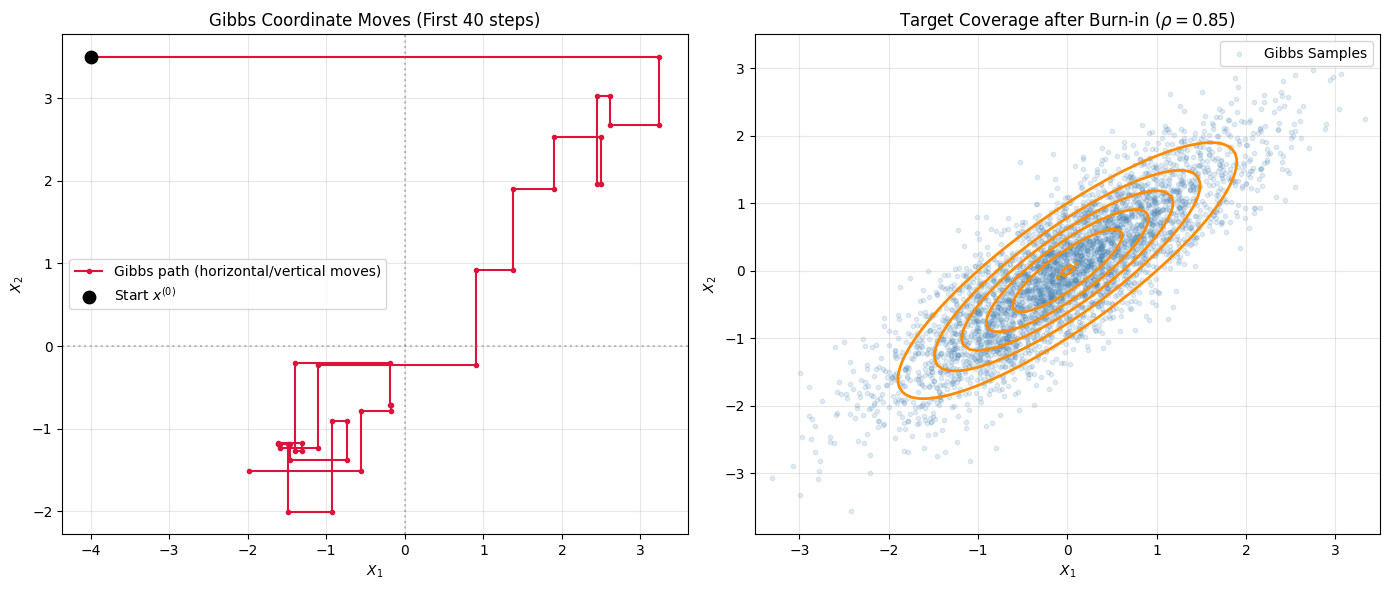

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run_gibbs_bivariate_normal(n_iterations=5000, rho=0.85, x_init=(-3.0, 3.0)):
    """
    Gibbs sampler for a 2D zero-mean Gaussian with correlation rho.
    Target: [X1, X2]^T ~ N([0, 0]^T, [[1, rho], [rho, 1]])
    """
    # Precompute standard deviation of the 1D conditional distributions
    cond_std = np.sqrt(1.0 - rho**2)
    
    # Storage arrays
    samples = np.empty((n_iterations, 2))
    
    # Store fine-grained steps (to visualize the characteristic "staircase" path)
    trajectory = []
    
    x1, x2 = x_init
    trajectory.append((x1, x2))
    
    for t in range(n_iterations):
        # 1. Update X1 conditioned on current X2
        #    X1 | X2=x2 ~ N(rho * x2, 1 - rho^2)
        mean_x1 = rho * x2
        x1 = np.random.normal(loc=mean_x1, scale=cond_std)
        trajectory.append((x1, x2))  # Horizontal move
        
        # 2. Update X2 conditioned on newly updated X1
        #    X2 | X1=x1 ~ N(rho * x1, 1 - rho^2)
        mean_x2 = rho * x1
        x2 = np.random.normal(loc=mean_x2, scale=cond_std)
        trajectory.append((x1, x2))  # Vertical move
        
        # Record iteration state
        samples[t] = [x1, x2]
        
    return samples, np.array(trajectory)

# Run the sampler
np.random.seed(42)
n_iter = 4000
burn_in = 200
rho = 0.85

samples, trajectory = run_gibbs_bivariate_normal(
    n_iterations=n_iter, 
    rho=rho, 
    x_init=(-4.0, 3.5)  # Start far in the tail
)

valid_samples = samples[burn_in:]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: The Gibbs "Staircase" Trajectory (First 40 coordinate updates)
axes[0].plot(trajectory[:40, 0], trajectory[:40, 1], color='crimson', lw=1.5, marker='o', markersize=3, label='Gibbs path (horizontal/vertical moves)')
axes[0].scatter(trajectory[0, 0], trajectory[0, 1], color='black', s=80, zorder=5, label='Start $x^{(0)}$')
axes[0].axhline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_title("Gibbs Coordinate Moves (First 40 steps)")
axes[0].set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

# Plot B: Empirical Joint Distribution vs. Theoretical Density Contours
x_grid = np.linspace(-3.5, 3.5, 100)
y_grid = np.linspace(-3.5, 3.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)

# Theoretical Bivariate Normal density formula for contour comparison
cov_matrix = np.array([[1.0, rho], [rho, 1.0]])
inv_cov = np.linalg.inv(cov_matrix)
det_cov = np.linalg.det(cov_matrix)
Z_theoretical = np.exp(-0.5 * (inv_cov[0, 0]*X**2 + 2*inv_cov[0, 1]*X*Y + inv_cov[1, 1]*Y**2)) / (2 * np.pi * np.sqrt(det_cov))

axes[1].scatter(valid_samples[:, 0], valid_samples[:, 1], alpha=0.15, color='steelblue', s=10, label='Gibbs Samples')
axes[1].contour(X, Y, Z_theoretical, levels=6, colors='darkorange', linewidths=2.0)
axes[1].set_title(f"Target Coverage after Burn-in ($\\{rho=:.2f}$)")
axes[1].set_xlabel("$X_1$")
axes[1].set_ylabel("$X_2$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(['Gibbs Samples', 'True Density Contours'], frameon=True)

plt.tight_layout()
plt.show()